In [1]:
using Distributions
using StatsBase
using PythonPlot
using DataFrames
using Optim
using NLsolve
using Setfield
using CSV
include("estimators.jl")
include("rem_theory.jl")

FIG_PATH = "/Users/elevien/Dropbox (Dartmouth College)/Apps/Overleaf/Finite Lineages Plos Journal/paper/figures"

"/Users/elevien/Dropbox (Dartmouth College)/Apps/Overleaf/Finite Lineages Plos Journal/paper/figures"

# Setup

In [2]:
cmap = get_cmap("plasma")

# Theory from REM

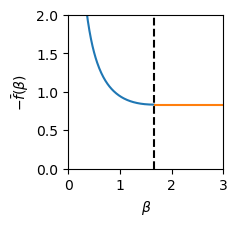

In [3]:
# first we just plot the free energy of the REM to see of the formulas make sense
βrng = collect(0.1:0.01:2*βc)
fig,ax = subplots(figsize=(2,2))
ax.plot(βrng[βrng .< βc],-fed_rem_ht.(βrng[βrng .< βc]))
ax.plot(βrng[βrng .> βc],-fed_rem_lt.(βrng[βrng .> βc]))
ax.vlines([βc],0,2,color="k",linestyle="--")
ax.set_ylim([0,2])
ax.set_xlim([0,3])
ax.set_ylabel(L"$-\bar{f}(\beta)$")
ax.set_xlabel(L"$\beta$")
fig

In [4]:
# compute theoretical predictions for Λ based on REM
θ = (n = 5,M = 20,t = 10, τ0=1,σ=0.1,α=0.03)
αrng_theory = collect(1.:0.2:800);
Lhats_theory = [Lhat_rem_theory(@set θ.α = a) for a in αrng_theory];


# Simulated data

In [5]:
FDE = CSV.read("./output/df_FDE",DataFrame);
Mrng_FDE = unique(FDE[:,end]);
αrng_FDE = CSV.read("./output/alpha_FDE",DataFrame).alpha;

FTE = CSV.read("./output/df_FTE",DataFrame);
Mrng_FTE = unique(FTE[:,end]);
αrng_FTE = CSV.read("./output/alpha_FTE",DataFrame).alpha;

Lhats_FDE = [Matrix(df[:,1:length(αrng_FDE)]) for df in groupby(FDE,length(αrng_FDE)+1)];
Lhats_FTE = [Matrix(df[:,1:length(αrng_FTE)]) for df in groupby(FTE,length(αrng_FTE)+1)];

# take mean and variance
Lhats_FDE_med = [median(y,dims=1)[1,:] for y in Lhats_FDE];
Lhats_FDE_var = [var(y,dims=1)[1,:] for y in Lhats_FDE];
Lhats_FTE_med = [median(y,dims=1)[1,:] for y in Lhats_FTE];
Lhats_FTE_var = [var(y,dims=1)[1,:] for y in Lhats_FTE];
 

19-element Vector{Vector{Float64}}:
 [8.44138765709423e-5, 1.0076260897326854e-5, 2.4188671741107173e-6, 5.733200899132009e-7, 3.285718550771189e-7, 1.9889365398201844e-7, 1.228072966888599e-7, 4.360487696169869e-8, 1.730307786948271e-8, 6.46945563435833e-9]
 [0.00010853238848895824, 5.187697178431473e-6, 1.2614912112862579e-6, 3.785214422207235e-7, 1.9684716053597295e-7, 2.265054056185005e-7, 1.2794029751936245e-7, 3.774697734670501e-8, 1.5837154945213007e-8, 4.932116434231606e-9]
 [5.319649100295691e-5, 4.0543118013085e-6, 6.872285699595659e-7, 2.5602938200348764e-7, 1.6839783625348995e-7, 1.8869279567846622e-7, 8.431861958118117e-8, 4.088333976761708e-8, 1.1645362541937198e-8, 2.9712878739437463e-9]
 [4.723558511453835e-5, 2.952184600913764e-6, 5.690253185445778e-7, 2.539826586472805e-7, 1.5197819896282282e-7, 1.759253195802607e-7, 1.2249973060745793e-7, 2.938167252652047e-8, 1.4404614836322156e-8, 4.2027425597289264e-9]
 [2.45569963521065e-5, 2.8059948670986044e-6, 5.87013420565135

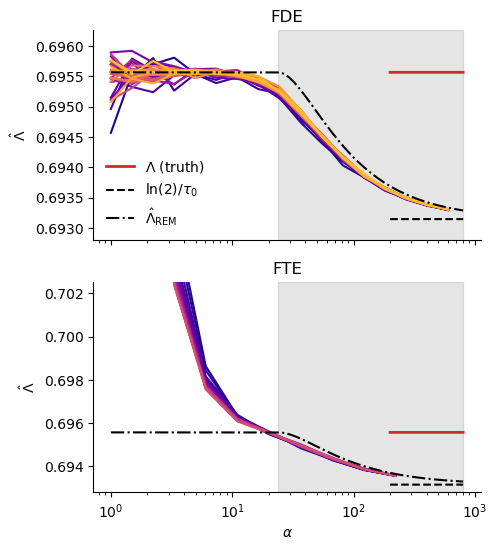

In [6]:
fig, axs= subplots(figsize=(5,6),sharex=true,nrows=2)
Ltrue = 2log(2)/(1+sqrt(1-2log(2)*θ.σ^2))


for k in 1:length(Lhats_FDE_med)

    axs[0].plot(αrng_FDE,Lhats_FDE_med[k],"-",color = cmap(k/(length(Lhats_FDE_med)+5)))
end

for k in 1:length(Lhats_FTE_med)
    axs[1].plot(αrng_FTE,Lhats_FTE_med[k],"-",color = cmap(k/(length(Lhats_FDE_med)+5)))
end

ymin,ymax = 0.9995*log(2),1.001*Ltrue
axs[0].set_ylim(ymin,ymax)
axs[1].set_ylim(ymin,1.01*Ltrue)
axs[0].set_title("FDE")
axs[1].set_title("FTE")

for ax in axs
    ax.plot(αrng_theory[end-3000:end],ones(length(αrng_theory[end-3000:end])) .* Ltrue,"C3",label=L"$\Lambda$ (truth)",lw=2)
    ax.plot(αrng_theory[end-3000:end],ones(length(αrng_theory[end-3000:end])) .* log(2),"k--",label=L"$\ln(2)/\tau_0$")
    ax.semilogx(αrng_theory,Lhats_theory,"k-.",label=L"$\hat{\Lambda}_{\rm REM}$")
    ax.set_ylabel(L"$\hat{\Lambda}$")
    ax.spines["right"].set_visible(false)
    ax.spines["top"].set_visible(false)
    
    ax.axvspan(βc/(Ltrue*θ.σ),αrng_theory[end], alpha=0.1, color="k")
end
axs[1].set_xlabel(L"$\alpha$")


axs[0].legend(frameon=true,loc=3,facecolor="white",framealpha=1,fancybox=false,edgecolor="w")


#fig.colorbar(cm.ScalarMappable(cmap=cmap), ax=ax)

savefig(FIG_PATH*"/phase_transition.pdf",bbox_inches="tight")

fig

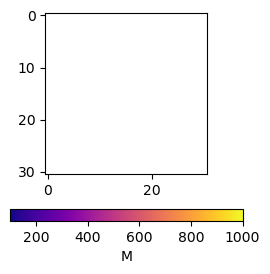

In [512]:
fig, ax= subplots(figsize=(3,3),sharey=true)
img = imshow(sqrt.(Mrng .* Mrng'), cmap=cmap)
img.set_visible(false)
c = colorbar(orientation="horizontal",label="M")
savefig(FIG_PATH*"/colorbar.pdf",bbox_inches="tight")
fig

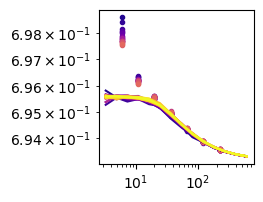

In [7]:
fig, ax= subplots(figsize=(2,2),sharey=true)
for k in 1:length(Lhats_FTE_med)
    ax.loglog(αrng_FTE[4:end],Lhats_FTE_med[k][4:end],".",color = cmap(k/length(Lhats_FDE_med)))
end

for k in 1:length(Lhats_FDE_med)
    ax.loglog(αrng_FDE[4:end],Lhats_FDE_med[k][4:end],"-",color = cmap(k/length(Lhats_FDE_med)))
end


fig

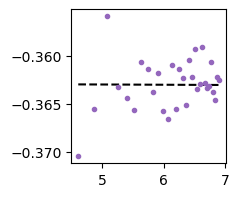

In [8]:
fig, ax= subplots(figsize=(2,2),sharey=true)
Ltrue = 2log(2)/(1+sqrt(1-2log(2)*θ.σ^2))

y = [log.(L[3]) for L in Lhats_FDE_med]
X = hcat(ones(length(y)),log.(Mrng_FDE))
inter,slope = inv(X'*X)*X'*y

ax.plot(log.(Mrng_FDE),log.(Mrng_FDE) *slope.+ inter,"k--")
ax.plot(log.(Mrng_FDE),[log.(L[3]) for L in Lhats_FDE],"C4.")
#savefig(FIG_PATH*"/phase_transition.pdf",bbox_inches="tight")
fig

PythonCall.Core.PyException: Python: AttributeError: 'Colorbar' object has no attribute 'write'

In [159]:
slope

7.003066100079507e-5

In [31]:
fig, ax= subplots(figsize=(8,4))
ax.semilogy(αrng_theory_corr,".")
fig

UndefVarError: UndefVarError: `αrng_theory_corr` not defined